In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from pathlib import Path

RESULTS = Path('../results')
DOMAINS = ['synthetic', 'lightbox', 'sunlamp']
DOMAIN_COLORS = {'synthetic': '#4C72B0', 'lightbox': '#DD8452', 'sunlamp': '#55A868'}

feature_names = np.load(RESULTS / 'img_stats_feature_names.npy', allow_pickle=True).tolist()

def load_features_and_errors(domain):
    X = np.load(RESULTS / f'img_stats_{domain}.npy')
    e = pd.read_csv(RESULTS / f'per_image_errors_{domain}.csv')['speed_score'].values
    n = min(len(X), len(e))
    return X[:n], e[:n]

print(f'{len(feature_names)} features: {feature_names}')


13 features: ['mean_brightness', 'std_brightness', 'overexposure_frac', 'underexposure_frac', 'brightness_skew', 'dynamic_range', 'img_entropy', 'lbp_variance', 'sharpness_laplacian', 'freq_ratio', 'edge_density', 'center_brightness', 'center_contrast']


In [2]:
# Compute Spearman rho between each feature and SPEED error, per domain
rho_table = {}   # domain -> (n_features,) array of rho values
pval_table = {}

for domain in DOMAINS:
    X, errors = load_features_and_errors(domain)
    rhos, pvals = [], []
    for j in range(X.shape[1]):
        rho, pval = spearmanr(X[:, j], errors)
        rhos.append(rho)
        pvals.append(pval)
    rho_table[domain]  = np.array(rhos)
    pval_table[domain] = np.array(pvals)

# Print summary
df_rho = pd.DataFrame(rho_table, index=feature_names)
df_rho.index.name = 'feature'
print('Spearman ρ (feature vs SPEED error):')
print(df_rho.round(3).to_string())


Spearman ρ (feature vs SPEED error):
                     synthetic  lightbox  sunlamp
feature                                          
mean_brightness         -0.058    -0.491    0.111
std_brightness          -0.026    -0.462    0.036
overexposure_frac        0.068    -0.410    0.035
underexposure_frac       0.090     0.473   -0.079
brightness_skew          0.082     0.260   -0.069
dynamic_range            0.035    -0.028   -0.150
img_entropy             -0.091    -0.440    0.122
lbp_variance            -0.066     0.462    0.079
sharpness_laplacian     -0.088    -0.017   -0.227
freq_ratio               0.007     0.489   -0.194
edge_density            -0.080    -0.336   -0.096
center_brightness       -0.117    -0.524    0.033
center_contrast         -0.067    -0.446   -0.054


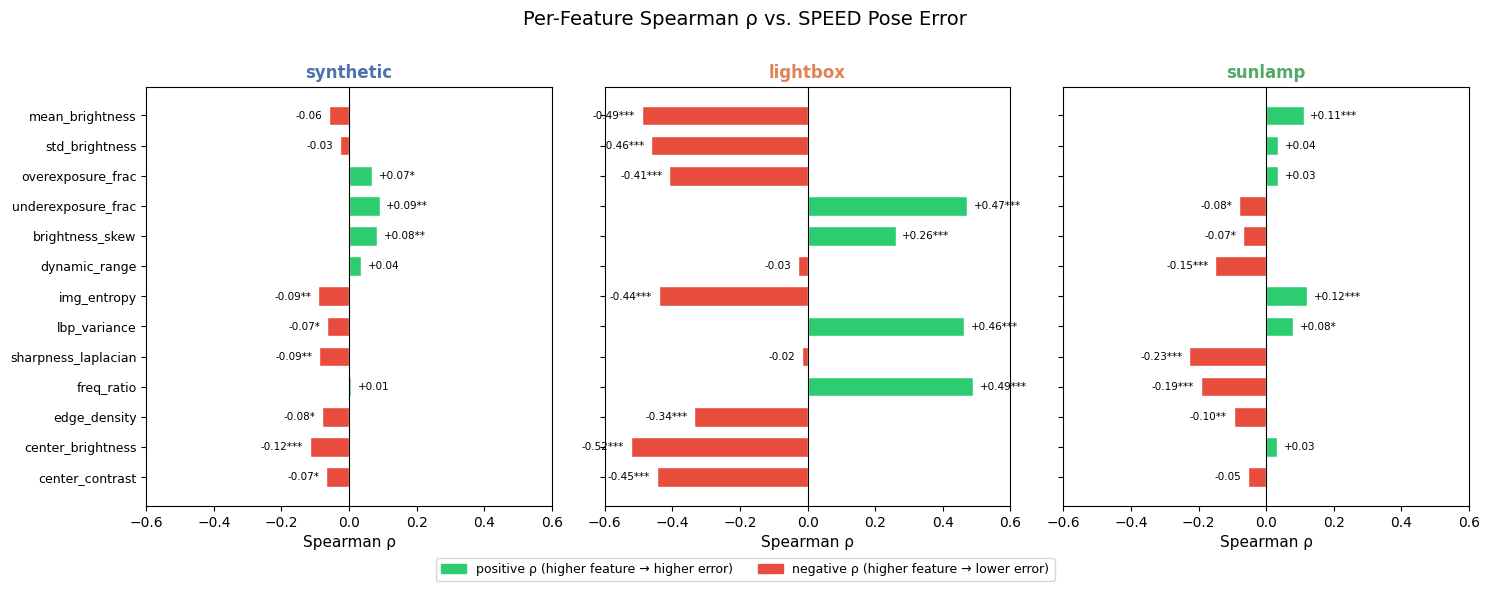

Saved → figures/feature_error_correlation.png


In [3]:
# Horizontal bar chart: one subplot per domain
# Bars colored green (positive rho) or red (negative rho)
# Stars mark significance: * p<0.05, ** p<0.01, *** p<0.001

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
fig.suptitle('Per-Feature Spearman ρ vs. SPEED Pose Error', fontsize=14, y=1.01)

n_feat = len(feature_names)
y_pos  = np.arange(n_feat)

for ax, domain in zip(axes, DOMAINS):
    rhos  = rho_table[domain]
    pvals = pval_table[domain]
    colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in rhos]

    bars = ax.barh(y_pos, rhos, color=colors, edgecolor='white', height=0.65)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-0.6, 0.6)
    ax.set_xlabel('Spearman ρ', fontsize=11)
    ax.set_title(domain, fontsize=12, color=DOMAIN_COLORS[domain], fontweight='bold')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.invert_yaxis()

    # annotate rho value + significance stars to the right of each bar
    for i, (rho, pval) in enumerate(zip(rhos, pvals)):
        stars = sig_stars(pval)
        label = f'{rho:+.2f}{stars}'
        x_off = 0.02 if rho >= 0 else -0.02
        ha    = 'left' if rho >= 0 else 'right'
        ax.text(rho + x_off, i, label, va='center', ha=ha, fontsize=7.5)

pos_patch = mpatches.Patch(color='#2ecc71', label='positive ρ (higher feature → higher error)')
neg_patch = mpatches.Patch(color='#e74c3c', label='negative ρ (higher feature → lower error)')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('../figures/feature_error_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/feature_error_correlation.png')
